In [1]:
import warnings
warnings.filterwarnings(action='ignore')

import numpy as np
import pandas as pd

# 시각화
import matplotlib.pyplot as plt
import matplotlib

# 한글 폰트(맑은 고딕) 설정
plt.rcParams['font.family'] = 'Malgun Gothic'

- kobis 데이터 로드

In [3]:
df = pd.read_csv('data/kobis.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3650 entries, 0 to 3649
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   날짜      3650 non-null   int64 
 1   순위      3650 non-null   int64 
 2   영화명     3650 non-null   object
 3   개봉일     3650 non-null   object
 4   일일관객수   3650 non-null   int64 
 5   누적관객수   3650 non-null   int64 
 6   일일매출액   3650 non-null   int64 
dtypes: int64(5), object(2)
memory usage: 199.7+ KB


In [6]:
# 일일매출액, 일일관객수의 평균값, 중앙값
df[['일일매출액', '일일관객수']].mean()
df[['일일매출액', '일일관객수']].median()
df[['일일매출액', '일일관객수']].agg(['mean', 'median'])

,일일매출액,일일관객수
mean,2.652728e+08,26874.885753
median,7.086890e+07,7320.000000


In [7]:
df.describe()

,날짜,순위,일일관객수,누적관객수,일일매출액
count,3.650000e+03,3650.000000,3650.000000,3.650000e+03,3.650000e+03
mean,2.025067e+07,5.500000,26874.885753,9.613494e+05,2.652728e+08
std,3.450492e+02,2.872675,56635.799237,1.444113e+06,5.748500e+08
min,2.025010e+07,1.000000,519.000000,1.048000e+03,2.230000e+06
25%,2.025040e+07,3.000000,3314.500000,5.198450e+04,3.121042e+07
50%,2.025070e+07,5.500000,7320.000000,2.928320e+05,7.086890e+07
75%,2.025100e+07,8.000000,23301.000000,1.200541e+06,2.236650e+08
max,2.025123e+07,10.000000,700790.000000,1.080952e+07,7.314982e+09


<Axes: title={'center': 'ㅇㅇ'}, xlabel='일일관객수', ylabel='일일매출액'>

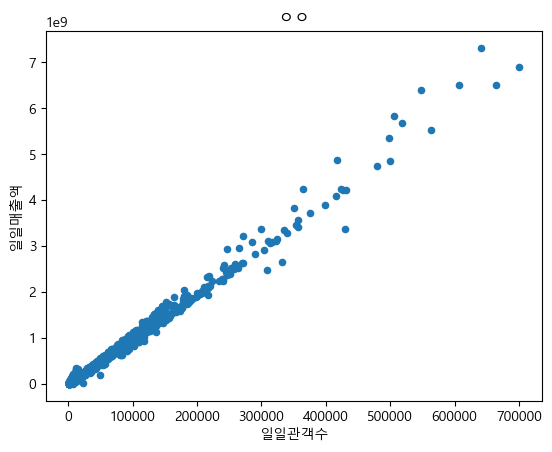

In [9]:
# 일일매출액, 일일관객수의 상관관계에 따른 산점도
df.plot.scatter(
    x = '일일관객수',
    y = '일일매출액',
    title = 'ㅇㅇ'
)

In [10]:
# mpg 데이터셋 로드
mpg_df = pd.read_csv('data/auto-mpg.csv')
mpg_df

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino
...,...,...,...,...,...,...,...,...,...
393,27.0,4,140.0,86,2790,15.6,82,1,ford mustang gl
394,44.0,4,97.0,52,2130,24.6,82,2,vw pickup
395,32.0,4,135.0,84,2295,11.6,82,1,dodge rampage
396,28.0,4,120.0,79,2625,18.6,82,1,ford ranger


In [12]:
# 무게와 연비 상관관계
mpg_df['weight'].corr(mpg_df['mpg'])

np.float64(-0.8317409332443351)

In [16]:
# 일일매출액과 일일관객수의 상관계수
r = df['일일매출액'].corr(df['일일관객수'])
print(f"r(상관계수): {r:.3f}")             # .3f : 소수점 세자리까지 표시

r(상관계수): 0.996


### mpg 컬럼에 이상치 데이터를 추가하면??

23.514572864321607
23.0


<Axes: >

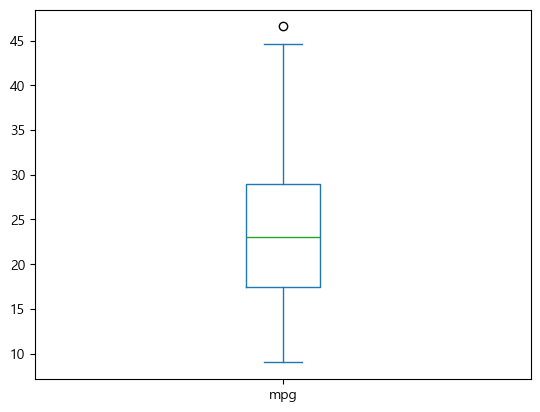

In [19]:
print(mpg_df['mpg'].mean())
print(mpg_df['mpg'].median())
mpg_df['mpg'].plot.box()

<Axes: >

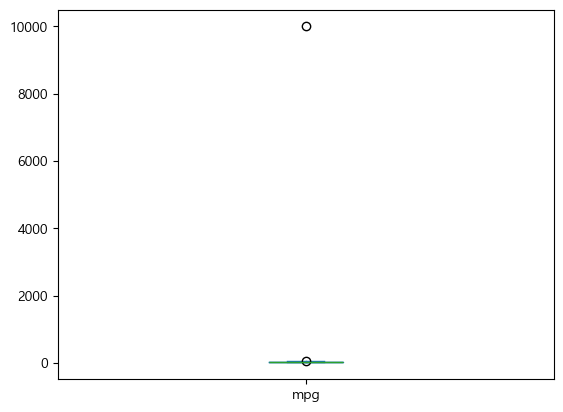

In [28]:
# 0번지 데이터의 mpg 10000으로 변경
mpg_df.loc[0, 'mpg'] = 10000
mpg_df['mpg'].plot.box()

In [30]:
# outlier가 있을 때 상관계수
mpg_df['weight'].corr(mpg_df['mpg'])            # r : -0.83 => r:0.018로 아예 바뀜

np.float64(0.01867792918153421)

In [50]:
# 이상치 조정 -> 삭제(drop), 중앙값(median), 이전값(ffill), 다음값(bfill)
mpg_df_new = mpg_df.drop(0)
outlier_new_val = mpg_df_new['mpg'].median()
mpg_df.loc[0, 'mpg'] = outlier_new_val
mpg_df.head()
mpg_df['weight'].corr(mpg_df['mpg'])

np.float64(-0.8312434968591064)

## iris dataset 상관계수

In [51]:
# 데이터셋 로드
iris_df = pd.read_csv('data/iris/iris.csv')
iris_df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [52]:
# 결측치 확인
iris_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [53]:
# 데이터 통계지표 확인
iris_df.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


<Axes: >

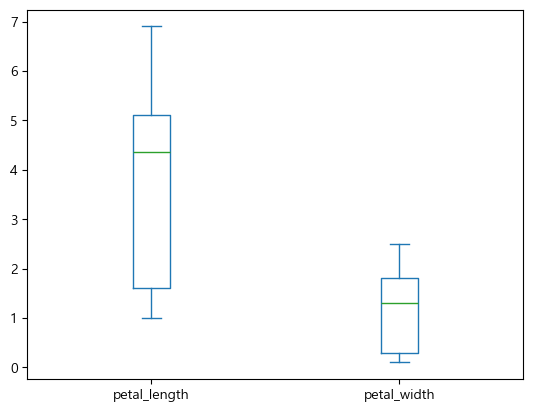

In [54]:
# 이상치 확인 (petal_length, petal_width)
iris_df[['petal_length', 'petal_width']].plot.box()

In [57]:
# 상관 계수 도출
iris_df['petal_length'].corr(iris_df['petal_width'])

np.float64(0.9627570970509663)

<Axes: xlabel='petal_length', ylabel='petal_width'>

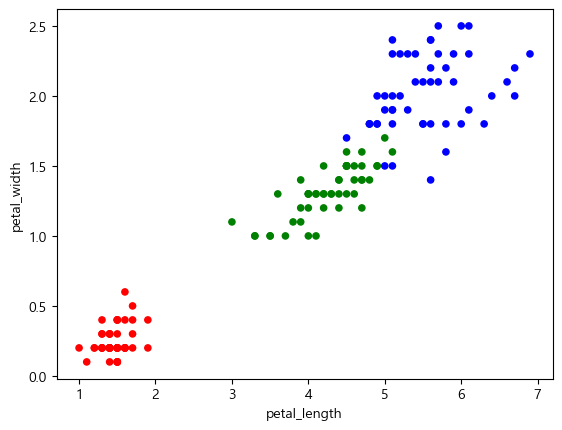

In [70]:
# 산점도 그래프 생성
colors = {
    "setosa" : "red",
    "versicolor" : "green",
    "virginica" : "blue"
}
colors = [colors[sp] for sp in iris_df.species]

iris_df.plot.scatter('petal_length', 'petal_width', c = colors)

<Axes: xlabel='petal_length', ylabel='petal_width'>

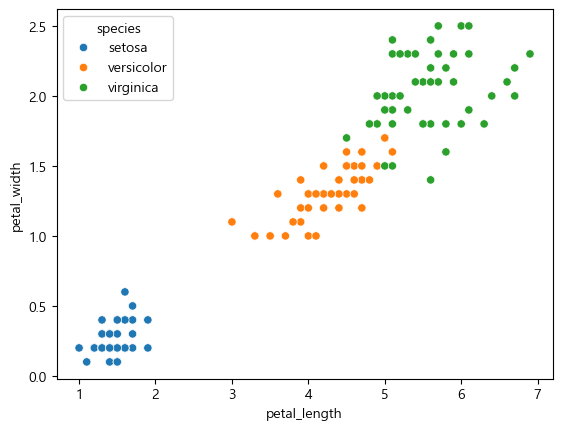

In [71]:
import seaborn as sns

sns.scatterplot(
    data=iris_df, 
    x='petal_length', 
    y='petal_width', 
    hue='species'
)

### 타이타닉 데이터셋의 나이와 요금의 상관 관계 도출

In [78]:
# 데이터셋 로드
titanic_df = pd.read_csv('data/titanic/train.csv')
titanic_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [79]:
# 데이터타입, 결측치 확인 등
titanic_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [80]:
# 통계지표 확인
titanic_df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


<Axes: >

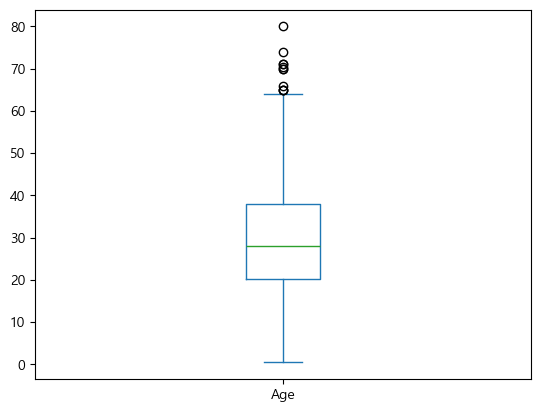

In [83]:
# 각 변수를 박스 플롯 생성
titanic_df['Age'].plot.box()

<Axes: >

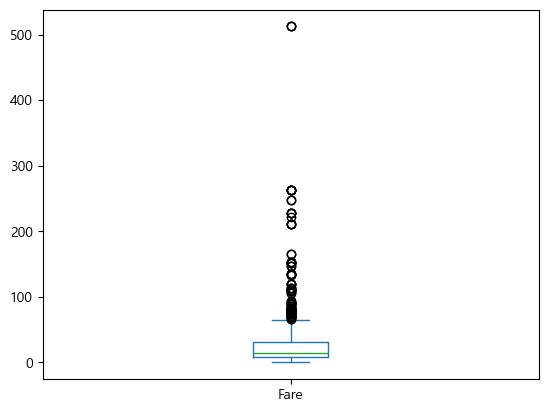

In [84]:
titanic_df['Fare'].plot.box()

In [85]:
# 상관 계수 구하기
titanic_df['Age'].corr(titanic_df['Fare'])

np.float64(0.09606669176903887)

<Axes: xlabel='Age', ylabel='Fare'>

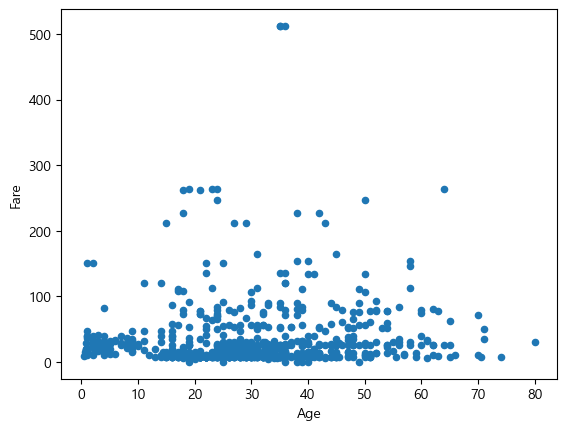

In [87]:
# 산점도 그래프 생성
titanic_df.plot.scatter(
    x = 'Age',
    y = 'Fare'
)